# A Logarithmic Number System (LNS) Library for DNN Computation

LNS16 / LNS8 -- conversion, log-domain arithmetic, and error analysis vs. FP32/FP16.

This notebook builds a small, importable Python package (`lns_lib`) implementing fixed-point LNS
arithmetic: two formats (LNS16, LNS8, each a sign bit plus a fixed-point two's-complement encoding
of `log2(|x|)`), conversion to/from FP32/FP16, and addition/multiplication/MAC performed entirely in
the log domain (multiplication is the exact identity `log(ab) = log(a)+log(b)`; addition uses the
Gaussian-logarithm method, the same technique real LNS hardware implements with a lookup table).
Positive/negative values, zero, overflow, underflow and rounding are all handled explicitly. The
last sections run a full error analysis against FP32/FP16 references and discuss the results.

Run all cells top to bottom (works in Google Colab). The early cells write the package to disk with
`%%writefile`, so this notebook is the source of the package -- copy the `lns_lib/` folder and
`README.md` it produces straight into a GitHub repo.


## 1. Format design

Both formats use the same encoding: 1 sign bit plus a two's-complement fixed-point field
representing `L = log2(|x|)`, split into `int_bits` (integer part, including that field's own sign)
and `frac_bits` (fractional part).

| Format | Total bits | Layout | log2-magnitude range | Representable magnitude range | Max quantization step (relative) |
|---|---|---|---|---|---|
| LNS16 | 16 | 1 sign + 8 int + 7 frac | [-128, 127.99] | ~2.96e-39 .. 3.38e+38 | ~0.27 % |
| LNS8  | 8  | 1 sign + 4 int + 3 frac | [-8, 7.875]     | ~4.26e-03 .. 2.35e+02 | ~4.43 % |

LNS16's 8/7 split brackets essentially the entire FP32 normal range (FP32 spans exponents
-126..127) while leaving 7 fractional bits (~0.27% max quantization step) for precision -- a
reasonable drop-in for FP32 tensors. LNS8's 4/3 split trades range for precision the other way: a
narrow window (~[0.004, 235]) typical of how low-bit-width formats get used for pre-scaled or
normalized DNN weights/activations. `int_bits`/`frac_bits` are configurable on `LNSFormat`, so other
splits are a one-line change.

`log2(0) = -infinity` has no finite fixed-point representation, so one code point -- the most
negative two's-complement value of the log field -- is reserved to mean `0.0`, the same trick
IEEE-754 uses reserving the all-zero exponent pattern for signed zero.

A result above the format's max representable code saturates to it (overflow); a result at or below
the smallest representable non-zero code flushes to zero (underflow). Both are reported back via a
`flags` dict. Converting a real log2 value to the fixed-point grid rounds to the nearest
representable code, ties away from zero, applied identically during conversion and after every
arithmetic operation.


## 2. Building the package

The next cells write out the full `lns_lib` package with `%%writefile`. This is exactly the code
that should be committed to the GitHub repo (`lns_lib/` folder + `pyproject.toml` + `README.md`,
all reproduced verbatim by this notebook).


In [ ]:
import os
os.makedirs('lns_lib', exist_ok=True)
os.makedirs('tests', exist_ok=True)
print('directories ready')

directories ready


In [ ]:
%%writefile lns_lib/format.py
"""
lns_lib.format

Bit layout for the two fixed-point LNS formats: LNS16 and LNS8.

Encoding: [ sign_bit (1) | log-magnitude, two's-complement fixed point (total_bits-1 bits) ]

The log-magnitude field is a signed fixed-point number representing
L = log2(|x|), split into int_bits (integer part, includes the field's
own sign) and frac_bits (fractional part). A field value c represents
c / 2**frac_bits.

log2(0) = -infinity, which has no finite representation, so the most
negative code of the log field is reserved and always decodes to 0.0
(same trick IEEE-754 uses for signed zero).

Any result above the max representable code saturates to it (overflow);
any result at or below the reserved zero code flushes to zero
(underflow). Both are reported back via a flags dict.
"""

from dataclasses import dataclass


@dataclass(frozen=True)
class LNSFormat:
    """A fixed-point LNS number format.

    name: human readable name, e.g. "LNS16".
    total_bits: total storage width (1 sign bit + log-magnitude field).
    int_bits: integer bits of the two's-complement log-magnitude field
        (includes that field's own sign).
    frac_bits: fractional bits of the log-magnitude field.
    """

    name: str
    total_bits: int
    int_bits: int
    frac_bits: int

    def __post_init__(self):
        if self.int_bits + self.frac_bits != self.total_bits - 1:
            raise ValueError(
                f"{self.name}: int_bits ({self.int_bits}) + frac_bits "
                f"({self.frac_bits}) must equal total_bits-1 "
                f"({self.total_bits - 1}); 1 bit is reserved for the "
                f"value's sign."
            )
        if self.int_bits < 1 or self.frac_bits < 0:
            raise ValueError(f"{self.name}: invalid int_bits/frac_bits split")

    @property
    def mag_bits(self) -> int:
        return self.int_bits + self.frac_bits

    @property
    def scale(self) -> int:
        """2**frac_bits: multiply a real log2 value by this to get the
        fixed-point integer code (before rounding)."""
        return 1 << self.frac_bits

    @property
    def logmag_min(self) -> int:
        """Most negative code; reserved as the zero sentinel."""
        return -(1 << (self.mag_bits - 1))

    @property
    def logmag_max(self) -> int:
        return (1 << (self.mag_bits - 1)) - 1

    @property
    def zero_code(self) -> int:
        return self.logmag_min

    @property
    def smallest_normal_logmag(self) -> int:
        return self.logmag_min + 1

    @property
    def L_min_real(self) -> float:
        return self.smallest_normal_logmag / self.scale

    @property
    def L_max_real(self) -> float:
        return self.logmag_max / self.scale

    @property
    def min_normal(self) -> float:
        return 2.0 ** self.L_min_real

    @property
    def max_normal(self) -> float:
        return 2.0 ** self.L_max_real

    @property
    def max_step_relative_error(self) -> float:
        """Worst-case relative quantization error from rounding L to the
        nearest code: half an ULP of the log field, converted to the
        linear domain."""
        half_ulp = 0.5 / self.scale
        return abs(2.0 ** half_ulp - 1.0)

    def describe(self) -> str:
        return (
            f"{self.name}: {self.total_bits} bits total "
            f"(1 sign + {self.int_bits} int + {self.frac_bits} frac log-field), "
            f"range [{self.min_normal:.6g}, {self.max_normal:.6g}], "
            f"max quantization step (relative) ~{self.max_step_relative_error * 100:.3f}%"
        )


# LNS16: 8/7 split -> log2 range +/-128, i.e. ~2^-128..2^127.99, chosen to
# bracket FP32's dynamic range (~2^-126..2^128 for normals).
LNS16 = LNSFormat(name="LNS16", total_bits=16, int_bits=8, frac_bits=7)

# LNS8: 4/3 split -> log2 range +/-8, i.e. ~2^-8..2^7.875, a narrow 8-bit
# format representative of low-precision DNN accumulator/weight formats.
LNS8 = LNSFormat(name="LNS8", total_bits=8, int_bits=4, frac_bits=3)


Writing lns_lib/format.py


In [ ]:
%%writefile lns_lib/convert.py
"""
lns_lib.convert

Conversion between IEEE floating point (FP32/FP16, via numpy) and the
fixed-point LNS formats in lns_lib.format.

LNSValue (a sign bit + integer log-magnitude code) is what arithmetic
operates on directly; lns_to_float is only used at the edges, to compare
an LNS result against a floating point reference.
"""

import math
from dataclasses import dataclass

import numpy as np

from .format import LNSFormat

FP32 = np.float32
FP16 = np.float16


def _round_half_away_from_zero(x: float) -> int:
    """Round to the nearest integer, ties away from zero (plain
    fixed-point rounding, not Python's round-half-to-even)."""
    if x >= 0:
        return math.floor(x + 0.5)
    return -math.floor(-x + 0.5)


@dataclass(frozen=True)
class LNSValue:
    """An encoded LNS number: a sign bit plus an integer log-magnitude
    code. logmag == fmt.logmag_min is the reserved zero sentinel."""

    sign: int  # 0 or 1
    logmag: int
    fmt: LNSFormat

    def __post_init__(self):
        if self.sign not in (0, 1):
            raise ValueError("sign must be 0 or 1")
        if not (self.fmt.logmag_min <= self.logmag <= self.fmt.logmag_max):
            raise ValueError(
                f"logmag code {self.logmag} out of range for {self.fmt.name}"
            )

    @property
    def is_zero(self) -> bool:
        return self.logmag == self.fmt.logmag_min

    def to_bits(self) -> int:
        """Pack into a single unsigned integer of fmt.total_bits bits,
        as it would sit in a hardware register."""
        mask = (1 << self.fmt.mag_bits) - 1
        mag_field = self.logmag & mask
        return (self.sign << self.fmt.mag_bits) | mag_field

    @classmethod
    def from_bits(cls, bits: int, fmt: LNSFormat) -> "LNSValue":
        mag_mask = (1 << fmt.mag_bits) - 1
        sign = (bits >> fmt.mag_bits) & 1
        raw = bits & mag_mask
        if raw & (1 << (fmt.mag_bits - 1)):  # sign-extend
            raw -= 1 << fmt.mag_bits
        return cls(sign=sign, logmag=raw, fmt=fmt)

    def __repr__(self):
        return (
            f"LNSValue({'-' if self.sign else '+'}, logmag={self.logmag}, "
            f"fmt={self.fmt.name}, value~={lns_to_float(self):.6g})"
        )


def _quantize_log(L: float, fmt: LNSFormat):
    """Quantize a real log2 magnitude to the format's fixed-point grid.
    Returns (code, flags)."""
    flags = {"overflow": False, "underflow": False}
    code = _round_half_away_from_zero(L * fmt.scale)
    if code > fmt.logmag_max:
        flags["overflow"] = True
        return fmt.logmag_max, flags
    if code <= fmt.logmag_min:
        flags["underflow"] = True
        return fmt.logmag_min, flags
    return code, flags


def float_to_lns(x, fmt: LNSFormat, ref_dtype=FP32):
    """Convert a real number to an LNSValue in format fmt.

    x is first snapped to ref_dtype (np.float32 or np.float16), modeling
    "quantize this FP32/FP16 value into LNS". Returns (LNSValue, flags).
    """
    xq = ref_dtype(x)
    xq_f = float(xq)

    if math.isnan(xq_f):
        raise ValueError("NaN has no LNS representation")

    if xq_f == 0.0:
        return LNSValue(0, fmt.logmag_min, fmt), {"overflow": False, "underflow": False}

    if math.isinf(xq_f):
        sign = 1 if xq_f < 0 else 0
        return LNSValue(sign, fmt.logmag_max, fmt), {"overflow": True, "underflow": False}

    sign = 1 if xq_f < 0 else 0
    mag = abs(xq_f)
    L = math.log2(mag)
    code, flags = _quantize_log(L, fmt)
    return LNSValue(sign, code, fmt), flags


def lns_to_float(v: LNSValue) -> float:
    """Decode an LNSValue back to a double-precision float. Only used for
    reporting/error analysis, never as an intermediate arithmetic step."""
    if v.is_zero:
        return 0.0
    L = v.logmag / v.fmt.scale
    mag = 2.0 ** L
    return -mag if v.sign else mag


def lns_to_fp32(v: LNSValue) -> np.float32:
    return np.float32(lns_to_float(v))


def lns_to_fp16(v: LNSValue) -> np.float16:
    return np.float16(lns_to_float(v))


Writing lns_lib/convert.py


In [ ]:
%%writefile lns_lib/arithmetic.py
"""
lns_lib.arithmetic

Addition, multiplication and multiply-accumulate performed entirely in
the log domain. Operands and results are LNSValue objects; an operand is
never converted back to a linear float in order to compute a result.

Multiplication is exact: log2(a*b) = log2(a) + log2(b), signs XOR. The
only error is the final re-quantization/saturation of the summed code.

Addition has no closed-form log-domain identity, so it uses the classical
Gaussian-logarithm method. With La = log2(|a|), Lb = log2(|b|), and
(after swapping so La >= Lb) r = Lb - La <= 0:

    same sign:     log2(|a|+|b|) = La + log2(1 + 2**r)      =: La + F+(r)
    opposite sign: log2(|a|-|b|) = La + log2(|1 - 2**r|)    =: La + F-(r)

F+ and F- depend only on r -- the difference of the two log codes, never
the operands' magnitudes. In hardware, r comes from an integer subtract
of the log fields and F+/F- are a lookup table indexed by r; here they're
evaluated with math.log2/** as a bit-accurate stand-in for that table
(see build_fplus_fminus_lut for an explicit, literally tabulated version).
"""

import math

from .convert import LNSValue, _round_half_away_from_zero
from .format import LNSFormat


def _saturate(code: int, fmt: LNSFormat):
    flags = {"overflow": False, "underflow": False}
    if code > fmt.logmag_max:
        flags["overflow"] = True
        return fmt.logmag_max, flags
    if code <= fmt.logmag_min:
        flags["underflow"] = True
        return fmt.logmag_min, flags
    return code, flags


def lns_mul(a: LNSValue, b: LNSValue):
    """Exact log-domain multiplication: logmags add, signs XOR."""
    if a.fmt is not b.fmt:
        raise ValueError("operands must share the same LNSFormat")
    fmt = a.fmt

    if a.is_zero or b.is_zero:
        return LNSValue(0, fmt.logmag_min, fmt), {"overflow": False, "underflow": False}

    sign = a.sign ^ b.sign
    raw = a.logmag + b.logmag
    code, flags = _saturate(raw, fmt)
    return LNSValue(sign, code, fmt), flags


def _fplus(r: float) -> float:
    """F+(r) = log2(1 + 2**r), r <= 0."""
    return math.log2(1.0 + 2.0 ** r)


def _fminus(r: float) -> float:
    """F-(r) = log2(|1 - 2**r|), r < 0 (r == 0 is exact cancellation,
    handled by the caller)."""
    return math.log2(abs(1.0 - 2.0 ** r))


def lns_add(a: LNSValue, b: LNSValue):
    """Add two LNS values via the Gaussian-logarithm method."""
    if a.fmt is not b.fmt:
        raise ValueError("operands must share the same LNSFormat")
    fmt = a.fmt

    if a.is_zero:
        return b, {"overflow": False, "underflow": False}
    if b.is_zero:
        return a, {"overflow": False, "underflow": False}

    if a.logmag >= b.logmag:
        big, small = a, b
    else:
        big, small = b, a

    if big.logmag == small.logmag and big.sign != small.sign:
        return LNSValue(0, fmt.logmag_min, fmt), {"overflow": False, "underflow": False}

    r = (small.logmag - big.logmag) / fmt.scale

    if big.sign == small.sign:
        delta = _fplus(r)
    else:
        delta = _fminus(r)
    result_sign = big.sign

    raw = big.logmag + _round_half_away_from_zero(delta * fmt.scale)
    code, flags = _saturate(raw, fmt)

    if code == fmt.logmag_min:
        return LNSValue(0, fmt.logmag_min, fmt), flags
    return LNSValue(result_sign, code, fmt), flags


def lns_sub(a: LNSValue, b: LNSValue):
    """a - b, via a + (-b); flipping the sign bit is exact."""
    fmt = a.fmt
    neg_b = b if b.is_zero else LNSValue(1 - b.sign, b.logmag, fmt)
    return lns_add(a, neg_b)


def lns_mac(acc: LNSValue, a: LNSValue, b: LNSValue):
    """acc + a*b, entirely in the log domain."""
    prod, flags_mul = lns_mul(a, b)
    result, flags_add = lns_add(acc, prod)
    flags = {
        "overflow": flags_mul["overflow"] or flags_add["overflow"],
        "underflow": flags_mul["underflow"] or flags_add["underflow"],
    }
    return result, flags


def lns_dot(acc: LNSValue, a_list, b_list):
    """acc + sum(a_i * b_i) via repeated lns_mac."""
    flags = {"overflow": False, "underflow": False}
    for a, b in zip(a_list, b_list):
        acc, f = lns_mac(acc, a, b)
        flags["overflow"] = flags["overflow"] or f["overflow"]
        flags["underflow"] = flags["underflow"] or f["underflow"]
    return acc, flags


# Explicit, literally-tabulated F+/F- lookup table -- mirrors how a real
# LNS adder would implement addition (a small ROM indexed by the
# quantized difference r), and serves as a correctness cross-check
# against the closed-form lns_add above.

_LUT_CACHE = {}


def build_fplus_fminus_lut(fmt: LNSFormat):
    """Build (and cache) quantized F+/F- lookup tables for fmt, indexed
    by k = |Lbig - Lsmall| over every value that difference can take."""
    key = fmt.name
    if key in _LUT_CACHE:
        return _LUT_CACHE[key]

    span = fmt.logmag_max - fmt.logmag_min
    fplus = {}
    fminus = {}
    for k in range(0, span + 1):
        r = -k / fmt.scale
        fplus[k] = _round_half_away_from_zero(_fplus(r) * fmt.scale)
        fminus[k] = None if k == 0 else _round_half_away_from_zero(_fminus(r) * fmt.scale)
    _LUT_CACHE[key] = (fplus, fminus)
    return fplus, fminus


def lns_add_lut(a: LNSValue, b: LNSValue):
    """Same as lns_add, but F+/F- come from a precomputed lookup table
    indexed by the integer difference of the log codes, matching lns_add
    to within its own rounding."""
    fmt = a.fmt
    if a.is_zero:
        return b, {"overflow": False, "underflow": False}
    if b.is_zero:
        return a, {"overflow": False, "underflow": False}

    if a.logmag >= b.logmag:
        big, small = a, b
    else:
        big, small = b, a

    if big.logmag == small.logmag and big.sign != small.sign:
        return LNSValue(0, fmt.logmag_min, fmt), {"overflow": False, "underflow": False}

    k = big.logmag - small.logmag
    fplus, fminus = build_fplus_fminus_lut(fmt)
    delta_code = fplus[k] if big.sign == small.sign else fminus[k]
    result_sign = big.sign

    raw = big.logmag + delta_code
    code, flags = _saturate(raw, fmt)
    if code == fmt.logmag_min:
        return LNSValue(0, fmt.logmag_min, fmt), flags
    return LNSValue(result_sign, code, fmt), flags


Writing lns_lib/arithmetic.py


In [ ]:
%%writefile lns_lib/metrics.py
"""
lns_lib.metrics

Error metrics for evaluating LNS conversion/arithmetic against FP32/FP16
references:

    relative_error = |x_ref - x_LNS| / |x_ref|   (x_ref != 0)
    relative_error = |x_ref - x_LNS|              (x_ref == 0, absolute error)
"""

from dataclasses import dataclass, field
from typing import List

import numpy as np


def error(ref: float, val: float) -> float:
    """Relative error, falling back to absolute error when ref == 0."""
    ref = float(ref)
    val = float(val)
    if ref == 0.0:
        return abs(val - ref)
    return abs(ref - val) / abs(ref)


@dataclass
class ErrorStats:
    label: str
    errors: List[float] = field(default_factory=list)

    def add(self, ref, val):
        self.errors.append(error(ref, val))

    @property
    def mean(self) -> float:
        return float(np.mean(self.errors)) if self.errors else float("nan")

    @property
    def max(self) -> float:
        return float(np.max(self.errors)) if self.errors else float("nan")

    @property
    def median(self) -> float:
        return float(np.median(self.errors)) if self.errors else float("nan")

    @property
    def count(self) -> int:
        return len(self.errors)

    def as_dict(self):
        return {
            "label": self.label,
            "count": self.count,
            "mean": self.mean,
            "median": self.median,
            "max": self.max,
        }

    def __repr__(self):
        return (
            f"{self.label:<28} n={self.count:<6} "
            f"mean={self.mean:.6e}  median={self.median:.6e}  max={self.max:.6e}"
        )


Writing lns_lib/metrics.py


In [ ]:
%%writefile lns_lib/__init__.py
"""
lns_lib -- a Logarithmic Number System (LNS) arithmetic library for DNN
computation experiments.

Formats: LNSFormat, LNS16, LNS8
Conversion: LNSValue, float_to_lns, lns_to_float, lns_to_fp32, lns_to_fp16
Arithmetic (log domain): lns_add, lns_sub, lns_mul, lns_mac, lns_dot,
    lns_add_lut, build_fplus_fminus_lut
Error metrics: error, ErrorStats
"""

from .format import LNSFormat, LNS16, LNS8
from .convert import LNSValue, float_to_lns, lns_to_float, lns_to_fp32, lns_to_fp16, FP32, FP16
from .arithmetic import (
    lns_add,
    lns_sub,
    lns_mul,
    lns_mac,
    lns_dot,
    lns_add_lut,
    build_fplus_fminus_lut,
)
from .metrics import error, ErrorStats

__all__ = [
    "LNSFormat",
    "LNS16",
    "LNS8",
    "LNSValue",
    "float_to_lns",
    "lns_to_float",
    "lns_to_fp32",
    "lns_to_fp16",
    "FP32",
    "FP16",
    "lns_add",
    "lns_sub",
    "lns_mul",
    "lns_mac",
    "lns_dot",
    "lns_add_lut",
    "build_fplus_fminus_lut",
    "error",
    "ErrorStats",
]

__version__ = "0.1.0"


Writing lns_lib/__init__.py


In [ ]:
%%writefile pyproject.toml
[build-system]
requires = ["setuptools>=61.0"]
build-backend = "setuptools.build_meta"

[project]
name = "lns-lib"
version = "0.1.0"
description = "A Logarithmic Number System (LNS) arithmetic library for DNN computation (LNS16 / LNS8, conversion + log-domain add/mul/MAC)."
readme = "README.md"
requires-python = ">=3.8"
dependencies = [
    "numpy",
]

[tool.setuptools]
packages = ["lns_lib"]


Writing pyproject.toml


In [ ]:
%%writefile tests/test_lns.py
"""
Correctness tests for lns_lib.

Run with: python -m pytest tests/ -v
or: python tests/test_lns.py
"""

import math
import random
import sys
import os

sys.path.insert(0, os.path.dirname(os.path.dirname(os.path.abspath(__file__))))

import numpy as np

from lns_lib import (
    LNS16,
    LNS8,
    float_to_lns,
    lns_to_float,
    lns_add,
    lns_sub,
    lns_mul,
    lns_mac,
    lns_add_lut,
    error,
)


def approx(a, b, tol):
    return abs(a - b) <= tol


def test_zero_roundtrip():
    for fmt in (LNS16, LNS8):
        v, flags = float_to_lns(0.0, fmt)
        assert v.is_zero
        assert lns_to_float(v) == 0.0
        assert not flags["overflow"] and not flags["underflow"]


def test_sign_roundtrip():
    for fmt in (LNS16, LNS8):
        for x in (1.0, -1.0, 3.5, -3.5):
            v, _ = float_to_lns(x, fmt)
            back = lns_to_float(v)
            assert (back < 0) == (x < 0) or x == 0
            assert error(x, back) < fmt.max_step_relative_error * 1.01


def test_roundtrip_precision_bound():
    random.seed(0)
    for fmt in (LNS16, LNS8):
        worst = 0.0
        for _ in range(5000):
            L = random.uniform(fmt.L_min_real + 1, fmt.L_max_real - 1)
            sign = random.choice([1, -1])
            x = sign * (2.0 ** L)
            v, flags = float_to_lns(x, fmt)
            assert not flags["overflow"] and not flags["underflow"]
            back = lns_to_float(v)
            e = error(x, back)
            worst = max(worst, e)
        assert worst <= fmt.max_step_relative_error * 1.05, (fmt.name, worst)


def test_multiplication_exactness():
    """Multiplication should introduce no error beyond what conversion
    already introduced in the two operands."""
    random.seed(1)
    for fmt in (LNS16, LNS8):
        for _ in range(2000):
            La = random.uniform(fmt.L_min_real / 2, fmt.L_max_real / 2)
            Lb = random.uniform(fmt.L_min_real / 2, fmt.L_max_real / 2)
            a = random.choice([1, -1]) * 2.0 ** La
            b = random.choice([1, -1]) * 2.0 ** Lb
            va, _ = float_to_lns(a, fmt)
            vb, _ = float_to_lns(b, fmt)
            prod, flags = lns_mul(va, vb)
            if flags["overflow"] or flags["underflow"]:
                continue
            got = lns_to_float(prod)
            ref = lns_to_float(va) * lns_to_float(vb)
            assert error(ref, got) < fmt.max_step_relative_error * 1.05


def test_addition_same_sign():
    fmt = LNS16
    a, _ = float_to_lns(3.0, fmt)
    b, _ = float_to_lns(4.0, fmt)
    r, flags = lns_add(a, b)
    assert approx(lns_to_float(r), 7.0, 7.0 * fmt.max_step_relative_error * 2)


def test_addition_opposite_sign_cancellation():
    fmt = LNS16
    a, _ = float_to_lns(5.0, fmt)
    b, _ = float_to_lns(-5.0, fmt)
    r, flags = lns_add(a, b)
    assert r.is_zero
    assert lns_to_float(r) == 0.0


def test_addition_opposite_sign_general():
    fmt = LNS16
    a, _ = float_to_lns(10.0, fmt)
    b, _ = float_to_lns(-3.0, fmt)
    r, flags = lns_add(a, b)
    got = lns_to_float(r)
    assert approx(got, 7.0, 7.0 * fmt.max_step_relative_error * 3)


def test_addition_identity_with_zero():
    fmt = LNS8
    a, _ = float_to_lns(2.5, fmt)
    z, _ = float_to_lns(0.0, fmt)
    r1, _ = lns_add(a, z)
    r2, _ = lns_add(z, a)
    assert lns_to_float(r1) == lns_to_float(a)
    assert lns_to_float(r2) == lns_to_float(a)


def test_subtraction():
    fmt = LNS16
    a, _ = float_to_lns(9.0, fmt)
    b, _ = float_to_lns(4.0, fmt)
    r, _ = lns_sub(a, b)
    assert approx(lns_to_float(r), 5.0, 5.0 * fmt.max_step_relative_error * 3)


def test_mac():
    fmt = LNS16
    acc, _ = float_to_lns(1.0, fmt)
    a, _ = float_to_lns(2.0, fmt)
    b, _ = float_to_lns(3.0, fmt)
    r, _ = lns_mac(acc, a, b)  # 1 + 2*3 = 7
    assert approx(lns_to_float(r), 7.0, 7.0 * fmt.max_step_relative_error * 3)


def test_overflow_saturates():
    fmt = LNS8
    big, flags = float_to_lns(1e10, fmt)  # beyond LNS8 range (~234.8 max)
    assert flags["overflow"]
    assert big.logmag == fmt.logmag_max


def test_underflow_flushes_to_zero():
    fmt = LNS8
    tiny, flags = float_to_lns(1e-10, fmt)  # below LNS8 range (~0.0039 min)
    assert flags["underflow"]
    assert tiny.is_zero


def test_add_matches_lut_variant():
    random.seed(2)
    fmt = LNS8
    for _ in range(500):
        a_f = random.choice([1, -1]) * (2.0 ** random.uniform(-6, 6))
        b_f = random.choice([1, -1]) * (2.0 ** random.uniform(-6, 6))
        va, _ = float_to_lns(a_f, fmt)
        vb, _ = float_to_lns(b_f, fmt)
        r1, _ = lns_add(va, vb)
        r2, _ = lns_add_lut(va, vb)
        assert r1.sign == r2.sign and r1.logmag == r2.logmag


def test_bit_packing_roundtrip():
    for fmt in (LNS16, LNS8):
        for x in (0.0, 1.0, -1.0, 123.0, -0.001):
            v, flags = float_to_lns(x, fmt)
            bits = v.to_bits()
            assert 0 <= bits < (1 << fmt.total_bits)
            from lns_lib import LNSValue
            v2 = LNSValue.from_bits(bits, fmt)
            assert v2.sign == v.sign and v2.logmag == v.logmag


def _run_all():
    tests = [obj for name, obj in list(globals().items()) if name.startswith("test_")]
    passed = 0
    for t in tests:
        t()
        passed += 1
        print(f"OK   {t.__name__}")
    print(f"\n{passed}/{len(tests)} tests passed")


if __name__ == "__main__":
    _run_all()


Writing tests/test_lns.py


### Install it as an importable package

`pip install -e .` builds `lns_lib` in editable mode from the files just written, so
`import lns_lib` below is importing the installed package, the same way a separate training/eval
script would.


In [ ]:
!pip install -e . -q

In [ ]:
import lns_lib
print('lns_lib version:', lns_lib.__version__)
print('Exports:', lns_lib.__all__)

lns_lib version: 0.1.0
Exports: ['LNSFormat', 'LNS16', 'LNS8', 'LNSValue', 'float_to_lns', 'lns_to_float', 'lns_to_fp32', 'lns_to_fp16', 'FP32', 'FP16', 'lns_add', 'lns_sub', 'lns_mul', 'lns_mac', 'lns_dot', 'lns_add_lut', 'build_fplus_fminus_lut', 'error', 'ErrorStats']


## 3. Correctness tests

Before trusting the error-analysis numbers below, `tests/test_lns.py` checks the library against
known-correct behaviour: round-trip conversion accuracy bounds, exact multiplication, addition for
same-sign/opposite-sign/exact-cancellation/identity-with-zero cases, subtraction, MAC, explicit
overflow and underflow triggering, agreement between the closed-form and lookup-table addition
implementations, and bit-packing round-trip.


In [ ]:
!python tests/test_lns.py

OK   test_zero_roundtrip
OK   test_sign_roundtrip


OK   test_roundtrip_precision_bound


OK   test_multiplication_exactness
OK   test_addition_same_sign
OK   test_addition_opposite_sign_cancellation
OK   test_addition_opposite_sign_general
OK   test_addition_identity_with_zero
OK   test_subtraction
OK   test_mac
OK   test_overflow_saturates
OK   test_underflow_flushes_to_zero
OK   test_add_matches_lut_variant
OK   test_bit_packing_roundtrip

14/14 tests passed


## 4. Usage demo -- explicit edge case handling

Positive numbers, negative numbers, zero, overflow, and underflow, shown directly rather than just
asserted in a test file.


In [ ]:

import lns_lib as lns

def show(x, fmt):
    v, flags = lns.float_to_lns(x, fmt)
    back = lns.lns_to_float(v)
    print(f"  x={x!r:>14}  ->  sign={v.sign} logmag={v.logmag:>6}  ->  back={back:.6g}   "
          f"flags={flags}")

for fmt in (lns.LNS16, lns.LNS8):
    print(f"--- {fmt.name} ---")
    show(3.75, fmt)          # ordinary positive
    show(-3.75, fmt)         # ordinary negative
    show(0.0, fmt)           # zero -> reserved sentinel code
    show(1e30, fmt)          # likely overflow for LNS8, fine for LNS16
    show(1e-30, fmt)         # likely underflow for LNS8, fine for LNS16
    print()


--- LNS16 ---
  x=          3.75  ->  sign=0 logmag=   244  ->  back=3.74834   flags={'overflow': False, 'underflow': False}
  x=         -3.75  ->  sign=1 logmag=   244  ->  back=-3.74834   flags={'overflow': False, 'underflow': False}
  x=           0.0  ->  sign=0 logmag=-16384  ->  back=0   flags={'overflow': False, 'underflow': False}
  x=         1e+30  ->  sign=0 logmag= 12756  ->  back=9.98897e+29   flags={'overflow': False, 'underflow': False}
  x=         1e-30  ->  sign=0 logmag=-12756  ->  back=1.0011e-30   flags={'overflow': False, 'underflow': False}

--- LNS8 ---
  x=          3.75  ->  sign=0 logmag=    15  ->  back=3.66802   flags={'overflow': False, 'underflow': False}
  x=         -3.75  ->  sign=1 logmag=    15  ->  back=-3.66802   flags={'overflow': False, 'underflow': False}
  x=           0.0  ->  sign=0 logmag=   -64  ->  back=0   flags={'overflow': False, 'underflow': False}
  x=         1e+30  ->  sign=0 logmag=    63  ->  back=234.753   flags={'overflow': Tru

In [ ]:

# Arithmetic entirely in the log domain
a, _ = lns.float_to_lns(6.0, lns.LNS16)
b, _ = lns.float_to_lns(2.5, lns.LNS16)
c, _ = lns.float_to_lns(-6.0, lns.LNS16)

add_res, _ = lns.lns_add(a, b)
mul_res, _ = lns.lns_mul(a, b)
mac_res, _ = lns.lns_mac(b, a, b)          # b + a*b = 2.5 + 6*2.5 = 17.5
cancel_res, _ = lns.lns_add(a, c)          # 6 + (-6) = 0 exactly

print("6.0 + 2.5        =", lns.lns_to_float(add_res),   " (ref 8.5)")
print("6.0 * 2.5        =", lns.lns_to_float(mul_res),   " (ref 15.0)")
print("2.5 + 6.0*2.5     =", lns.lns_to_float(mac_res),  " (ref 17.5)")
print("6.0 + (-6.0)      =", lns.lns_to_float(cancel_res), " (ref 0.0, is_zero =", cancel_res.is_zero, ")")


6.0 + 2.5        = 8.491017818314097  (ref 8.5)
6.0 * 2.5        = 14.9933410728824  (ref 15.0)
2.5 + 6.0*2.5     = 17.448123722644123  (ref 17.5)
6.0 + (-6.0)      = 0.0  (ref 0.0, is_zero = True )


## 5. Error analysis vs. FP32 / FP16

`analysis.py` (written out below and then imported) runs two experiments. CORE uses test values
(zero, positive/negative small, positive/negative large, wide log-uniform random, and
normal/DNN-weight-like random) sized to mostly land inside every format's representable range, so
the reported mean/max relative error reflects quantization precision rather than saturation. STRESS
uses values spanning ~the full FP32 dynamic range (`2^-135 .. 2^125`) to characterise
overflow/underflow incidence, i.e. how the formats' ranges differ.

Relative error is `|x_ref - x_LNS| / |x_ref|`, falling back to absolute error when `x_ref == 0`
(`lns_lib.metrics.error`).


In [ ]:
%%writefile analysis.py
"""
End-to-end error analysis of lns_lib against FP32/FP16 references.

Two experiments:

  CORE  -- test values sized to mostly fall inside every format's range
           (including LNS8's narrow one), so the reported mean/max error
           reflects quantization precision rather than saturation.
  STRESS -- values spanning ~the full FP32 dynamic range, used to
            characterise overflow/underflow incidence per format.

Run: python analysis.py
"""

import os

import numpy as np
import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt

from lns_lib import (
    LNS16,
    LNS8,
    FP32,
    FP16,
    float_to_lns,
    lns_to_float,
    lns_add,
    lns_mul,
    lns_mac,
    error,
    ErrorStats,
)

np.seterr(over="ignore", invalid="ignore")  # non-finite refs are detected & skipped explicitly

RNG = np.random.default_rng(42)
FIGDIR = os.path.join(os.path.dirname(os.path.abspath(__file__)), "figures")
os.makedirs(FIGDIR, exist_ok=True)


def make_core_vectors(n_each=2000):
    vecs = {}
    vecs["zero"] = np.zeros(16)
    vecs["positive_small"] = RNG.uniform(1e-3, 1e-1, n_each)
    vecs["negative_small"] = -RNG.uniform(1e-3, 1e-1, n_each)
    vecs["positive_large"] = RNG.uniform(10.0, 200.0, n_each)
    vecs["negative_large"] = -RNG.uniform(10.0, 200.0, n_each)
    signs = RNG.choice([-1.0, 1.0], n_each)
    logmag = RNG.uniform(-7, 7, n_each)  # ~[0.0078, 128]
    vecs["random_loguniform"] = signs * (2.0 ** logmag)
    vecs["random_normal_dnn"] = RNG.normal(0.0, 0.05, n_each)
    return vecs


def make_stress_vectors(n=6000):
    signs = RNG.choice([-1.0, 1.0], n)
    logmag = RNG.uniform(-135, 125, n)
    return {"stress_wide_range": signs * (2.0 ** logmag)}


def all_values(vecs):
    return np.concatenate(list(vecs.values()))


def safe_ref(x, ref_dtype):
    """Cast into ref_dtype and back; None if that overflows to +/-inf."""
    rf = float(ref_dtype(x))
    return rf if np.isfinite(rf) else None


def evaluate_conversion(values, fmt, ref_dtype, in_range_only=False):
    stats = ErrorStats(label=f"{fmt.name} conv (ref={ref_dtype.__name__})")
    overflow_ct = underflow_ct = skipped = 0
    n_seen = 0
    for x in values:
        ref = safe_ref(x, ref_dtype)
        if ref is None:
            skipped += 1
            continue
        n_seen += 1
        v, flags = float_to_lns(ref, fmt, ref_dtype=ref_dtype)
        overflow_ct += flags["overflow"]
        underflow_ct += flags["underflow"]
        if in_range_only and (flags["overflow"] or flags["underflow"]):
            continue
        got = lns_to_float(v)
        stats.add(ref, got)
    return stats, overflow_ct, underflow_ct, skipped, n_seen


def make_pairs(values, n_pairs, rng):
    idx_a = rng.integers(0, len(values), n_pairs)
    idx_b = rng.integers(0, len(values), n_pairs)
    return values[idx_a], values[idx_b]


def evaluate_op(a_vals, b_vals, fmt, ref_dtype, op, in_range_only=False):
    stats = ErrorStats(label=f"{fmt.name} {op} (ref={ref_dtype.__name__})")
    overflow_ct = underflow_ct = skipped = 0
    n_seen = 0
    n = len(a_vals)
    c_vals = RNG.uniform(-1, 1, n) if op == "mac" else None

    for i in range(n):
        a_ref = safe_ref(a_vals[i], ref_dtype)
        b_ref = safe_ref(b_vals[i], ref_dtype)
        if a_ref is None or b_ref is None:
            skipped += 1
            continue

        va, fa = float_to_lns(a_ref, fmt, ref_dtype=ref_dtype)
        vb, fb = float_to_lns(b_ref, fmt, ref_dtype=ref_dtype)

        if op == "add":
            ref_result = safe_ref(ref_dtype(a_ref) + ref_dtype(b_ref), ref_dtype)
            r, flags = lns_add(va, vb)
        elif op == "mul":
            ref_result = safe_ref(ref_dtype(a_ref) * ref_dtype(b_ref), ref_dtype)
            r, flags = lns_mul(va, vb)
        elif op == "mac":
            c_ref = safe_ref(c_vals[i], ref_dtype)
            if c_ref is None:
                skipped += 1
                continue
            vc, fc = float_to_lns(c_ref, fmt, ref_dtype=ref_dtype)
            ref_result = safe_ref(ref_dtype(c_ref) + ref_dtype(a_ref) * ref_dtype(b_ref), ref_dtype)
            r, flags = lns_mac(vc, va, vb)
            flags = {
                "overflow": flags["overflow"] or fc["overflow"],
                "underflow": flags["underflow"] or fc["underflow"],
            }
        else:
            raise ValueError(op)

        if ref_result is None:
            skipped += 1
            continue

        any_overflow = flags["overflow"] or fa["overflow"] or fb["overflow"]
        any_underflow = flags["underflow"] or fa["underflow"] or fb["underflow"]
        overflow_ct += any_overflow
        underflow_ct += any_underflow
        n_seen += 1
        if in_range_only and (any_overflow or any_underflow):
            continue

        got = lns_to_float(r)
        stats.add(ref_result, got)

    return stats, overflow_ct, underflow_ct, skipped, n_seen


def print_format_table():
    print("=" * 104)
    print("Format geometry / representable range / worst-case quantization step")
    print("=" * 104)
    rows = [
        ("FP32", "1 sign + 8 exp + 23 mant",
         f"~{np.finfo(np.float32).tiny:.3e} .. {np.finfo(np.float32).max:.3e}",
         f"{2.0**-23 * 100:.6f} %"),
        ("FP16", "1 sign + 5 exp + 10 mant",
         f"~{np.finfo(np.float16).tiny:.3e} .. {np.finfo(np.float16).max:.3e}",
         f"{2.0**-10 * 100:.4f} %"),
        (LNS16.name, f"1 sign + {LNS16.int_bits} int + {LNS16.frac_bits} frac (log field)",
         f"~{LNS16.min_normal:.3e} .. {LNS16.max_normal:.3e}",
         f"{LNS16.max_step_relative_error * 100:.4f} %"),
        (LNS8.name, f"1 sign + {LNS8.int_bits} int + {LNS8.frac_bits} frac (log field)",
         f"~{LNS8.min_normal:.3e} .. {LNS8.max_normal:.3e}",
         f"{LNS8.max_step_relative_error * 100:.4f} %"),
    ]
    print(f"{'Format':<8}{'Layout':<32}{'Representable magnitude range':<38}{'Max quant. step (rel.)'}")
    for r in rows:
        print(f"{r[0]:<8}{r[1]:<32}{r[2]:<38}{r[3]}")
    print()


def main():
    print_format_table()

    core_vecs = make_core_vectors(n_each=2000)
    core_values = all_values(core_vecs)
    print(f"CORE test set size: {len(core_values)} (zero/small/large/positive/negative/random)\n")

    formats = [LNS16, LNS8]
    ref_dtypes = [FP32, FP16]

    print("=" * 104)
    print("CORE PRECISION TABLE -- round-trip conversion error (FP -> LNS -> FP), in-range samples only")
    print("=" * 104)
    conv_results = {}
    for fmt in formats:
        for ref_dtype in ref_dtypes:
            stats, ov, uv, sk, n = evaluate_conversion(core_values, fmt, ref_dtype, in_range_only=True)
            conv_results[(fmt.name, ref_dtype.__name__)] = stats
            print(f"{stats}  [overflow={ov}/{n} underflow={uv}/{n} skipped(out of ref range)={sk}]")
    print()

    print("=" * 104)
    print("CORE PRECISION TABLE -- arithmetic error (add / mul / mac), entirely in the LNS log domain, in-range samples only")
    print("=" * 104)
    n_pairs = 4000
    a_vals, b_vals = make_pairs(core_values, n_pairs, RNG)
    n_force = 200
    force_mag = 2.0 ** RNG.uniform(-6, 6, n_force)
    a_vals = np.concatenate([a_vals, force_mag])
    b_vals = np.concatenate([b_vals, -force_mag * RNG.uniform(0.98, 1.02, n_force)])

    op_results = {}
    for fmt in formats:
        for ref_dtype in ref_dtypes:
            for op in ("add", "mul", "mac"):
                stats, ov, uv, sk, n = evaluate_op(a_vals, b_vals, fmt, ref_dtype, op, in_range_only=True)
                op_results[(fmt.name, ref_dtype.__name__, op)] = stats
                print(f"{stats}  [overflow={ov}/{n} underflow={uv}/{n} skipped={sk}]")
    print()

    print("=" * 104)
    print("STRESS TEST -- overflow/underflow incidence across ~full FP32 dynamic range (ref=FP32)")
    print("=" * 104)
    stress_vecs = make_stress_vectors(n=8000)
    stress_values = all_values(stress_vecs)
    stress_summary = {}
    for fmt in formats:
        stats, ov, uv, sk, n = evaluate_conversion(stress_values, fmt, FP32, in_range_only=False)
        stress_summary[fmt.name] = (ov, uv, n)
        print(f"{fmt.name}: overflow={ov} ({100*ov/n:.1f}%)  underflow={uv} ({100*uv/n:.1f}%)  "
              f"in-range={n-ov-uv} ({100*(n-ov-uv)/n:.1f}%)  representable range={fmt.min_normal:.3e}..{fmt.max_normal:.3e}")
    print()

    plot_conversion_scatter(core_vecs, formats, FP32)
    plot_summary_bars(conv_results, op_results, formats, ref_dtypes)
    plot_range_diagram(formats)

    return conv_results, op_results, stress_summary


def plot_conversion_scatter(vecs, formats, ref_dtype):
    fig, axes = plt.subplots(1, len(formats), figsize=(12, 5), sharey=True)
    for ax, fmt in zip(axes, formats):
        xs, es = [], []
        for cat, arr in vecs.items():
            for x in arr:
                ref = safe_ref(x, ref_dtype)
                if ref is None or ref == 0.0:
                    continue
                v, flags = float_to_lns(ref, fmt, ref_dtype=ref_dtype)
                if flags["overflow"] or flags["underflow"]:
                    continue
                got = lns_to_float(v)
                xs.append(abs(ref))
                es.append(error(ref, got))
        ax.scatter(xs, es, s=4, alpha=0.3)
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.axhline(fmt.max_step_relative_error, color="red", linestyle="--",
                    label=f"theoretical max step ({fmt.max_step_relative_error*100:.3f}%)")
        ax.set_title(f"{fmt.name} conversion error vs magnitude")
        ax.set_xlabel("|reference value| (log scale)")
        ax.legend(fontsize=8)
    axes[0].set_ylabel("relative error (log scale)")
    fig.tight_layout()
    path = os.path.join(FIGDIR, "conversion_error_scatter.png")
    fig.savefig(path, dpi=130)
    plt.close(fig)
    print(f"Saved {path}")


def plot_summary_bars(conv_results, op_results, formats, ref_dtypes):
    ops = ["add", "mul", "mac"]
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    width = 0.18
    for ax, metric in zip(axes, ["mean", "max"]):
        labels = ["conv"] + ops
        x = np.arange(len(labels))
        offset = -1.5
        for fmt in formats:
            for ref_dtype in ref_dtypes:
                vals = [getattr(conv_results[(fmt.name, ref_dtype.__name__)], metric)]
                for op in ops:
                    vals.append(getattr(op_results[(fmt.name, ref_dtype.__name__, op)], metric))
                ax.bar(x + offset * width, vals, width=width,
                       label=f"{fmt.name}/{ref_dtype.__name__}")
                offset += 1
        ax.set_yscale("log")
        ax.set_xticks(x)
        ax.set_xticklabels(labels)
        ax.set_title(f"{metric} relative error (in-range samples)")
        ax.set_ylabel("relative error (log scale)")
    axes[0].legend(fontsize=7, ncol=2)
    fig.tight_layout()
    path = os.path.join(FIGDIR, "error_summary_bars.png")
    fig.savefig(path, dpi=130)
    plt.close(fig)
    print(f"Saved {path}")


def plot_range_diagram(formats):
    fig, ax = plt.subplots(figsize=(10, 3))
    items = [
        ("FP32", np.finfo(np.float32).tiny, np.finfo(np.float32).max),
        ("FP16", np.finfo(np.float16).tiny, np.finfo(np.float16).max),
        ("LNS16", LNS16.min_normal, LNS16.max_normal),
        ("LNS8", LNS8.min_normal, LNS8.max_normal),
    ]
    for i, (name, lo, hi) in enumerate(items):
        ax.plot([np.log10(lo), np.log10(hi)], [i, i], linewidth=8, solid_capstyle="butt")
        ax.text(np.log10(hi) + 1, i, name, va="center")
    ax.set_yticks([])
    ax.set_xlabel("log10(representable positive magnitude)")
    ax.set_title("Representable dynamic range comparison")
    ax.set_xlim(-45, 50)
    fig.tight_layout()
    path = os.path.join(FIGDIR, "range_comparison.png")
    fig.savefig(path, dpi=130)
    plt.close(fig)
    print(f"Saved {path}")


if __name__ == "__main__":
    main()


Writing analysis.py


In [ ]:
import analysis
conv_results, op_results, stress_summary = analysis.main()

Format geometry / representable range / worst-case quantization step
Format  Layout                          Representable magnitude range         Max quant. step (rel.)
FP32    1 sign + 8 exp + 23 mant        ~1.175e-38 .. 3.403e+38               0.000012 %
FP16    1 sign + 5 exp + 10 mant        ~6.104e-05 .. 6.550e+04               0.0977 %
LNS16   1 sign + 8 int + 7 frac (log field)~2.955e-39 .. 3.384e+38               0.2711 %
LNS8    1 sign + 4 int + 3 frac (log field)~4.260e-03 .. 2.348e+02               4.4274 %

CORE test set size: 12016 (zero/small/large/positive/negative/random)

CORE PRECISION TABLE -- round-trip conversion error (FP -> LNS -> FP), in-range samples only
LNS16 conv (ref=float32)     n=12016  mean=1.347987e-03  median=1.342788e-03  max=2.710709e-03  [overflow=0/12016 underflow=0/12016 skipped(out of ref range)=0]
LNS16 conv (ref=float16)     n=12016  mean=1.347859e-03  median=1.337408e-03  max=2.710311e-03  [overflow=0/12016 underflow=0/12016 skipped(out of r

LNS8 conv (ref=float16)      n=11765  mean=2.183290e-02  median=2.188909e-02  max=4.409134e-02  [overflow=0/12016 underflow=251/12016 skipped(out of ref range)=0]

CORE PRECISION TABLE -- arithmetic error (add / mul / mac), entirely in the LNS log domain, in-range samples only
LNS16 add (ref=float32)      n=4200   mean=2.825694e-02  median=1.710681e-03  max=1.981176e+01  [overflow=0/4200 underflow=0/4200 skipped=0]
LNS16 mul (ref=float32)      n=4200   mean=1.780972e-03  median=1.532157e-03  max=5.370255e-03  [overflow=0/4200 underflow=0/4200 skipped=0]


LNS16 mac (ref=float32)      n=4200   mean=2.929404e-03  median=1.715371e-03  max=1.000000e+00  [overflow=0/4200 underflow=0/4200 skipped=0]
LNS16 add (ref=float16)      n=4200   mean=2.057524e-02  median=1.729964e-03  max=8.881209e+00  [overflow=0/4200 underflow=0/4200 skipped=0]
LNS16 mul (ref=float16)      n=4200   mean=1.802605e-03  median=1.525298e-03  max=5.207160e-02  [overflow=0/4200 underflow=0/4200 skipped=0]


LNS16 mac (ref=float16)      n=4200   mean=2.687013e-03  median=1.776605e-03  max=1.000000e+00  [overflow=0/4200 underflow=0/4200 skipped=0]
LNS8 add (ref=float32)       n=3947   mean=1.236927e-01  median=2.631600e-02  max=1.730519e+01  [overflow=71/4200 underflow=182/4200 skipped=0]
LNS8 mul (ref=float32)       n=2464   mean=2.900238e-02  median=2.527278e-02  max=8.777563e-02  [overflow=634/4200 underflow=1102/4200 skipped=0]
LNS8 mac (ref=float32)       n=2458   mean=4.670152e-02  median=3.097660e-02  max=5.148966e+00  [overflow=634/4200 underflow=1112/4200 skipped=0]


LNS8 add (ref=float16)       n=3948   mean=1.227156e-01  median=2.634619e-02  max=1.728571e+01  [overflow=71/4200 underflow=181/4200 skipped=0]
LNS8 mul (ref=float16)       n=2463   mean=2.905517e-02  median=2.537869e-02  max=8.824673e-02  [overflow=634/4200 underflow=1103/4200 skipped=0]
LNS8 mac (ref=float16)       n=2447   mean=4.780501e-02  median=3.030303e-02  max=5.349100e+00  [overflow=634/4200 underflow=1121/4200 skipped=0]

STRESS TEST -- overflow/underflow incidence across ~full FP32 dynamic range (ref=FP32)
LNS16: overflow=0 (0.0%)  underflow=212 (2.6%)  in-range=7788 (97.3%)  representable range=2.955e-39..3.384e+38
LNS8: overflow=3665 (45.8%)  underflow=3840 (48.0%)  in-range=495 (6.2%)  representable range=4.260e-03..2.348e+02



Saved /home/claude/nb_run2/figures/conversion_error_scatter.png


Saved /home/claude/nb_run2/figures/error_summary_bars.png
Saved /home/claude/nb_run2/figures/range_comparison.png


### 5.1 Conversion round-trip error (FP -> LNS -> FP), summarised as a table

In [ ]:

import pandas as pd

rows = []
for (fmt_name, ref_name), stats in conv_results.items():
    rows.append({"format": fmt_name, "reference": ref_name, **{k: v for k, v in stats.as_dict().items() if k != "label"}})
df_conv = pd.DataFrame(rows).sort_values(["format", "reference"]).reset_index(drop=True)
df_conv


,format,reference,count,mean,median,max
0,LNS16,float16,12016,0.001348,0.001337,0.002710
1,LNS16,float32,12016,0.001348,0.001343,0.002711
2,LNS8,float16,11765,0.021833,0.021889,0.044091
3,LNS8,float32,11765,0.021833,0.021876,0.044273


### 5.2 Arithmetic error (add / mul / mac), summarised as a table

In [ ]:

rows = []
for (fmt_name, ref_name, op), stats in op_results.items():
    rows.append({"format": fmt_name, "reference": ref_name, "op": op,
                 **{k: v for k, v in stats.as_dict().items() if k != "label"}})
df_ops = pd.DataFrame(rows).sort_values(["op", "format", "reference"]).reset_index(drop=True)
df_ops


,format,reference,op,count,mean,median,max
0,LNS16,float16,add,4200,0.020575,0.001730,8.881209
1,LNS16,float32,add,4200,0.028257,0.001711,19.811755
2,LNS8,float16,add,3948,0.122716,0.026346,17.285714
3,LNS8,float32,add,3947,0.123693,0.026316,17.305187
4,LNS16,float16,mac,4200,0.002687,0.001777,1.000000
5,LNS16,float32,mac,4200,0.002929,0.001715,1.000000
6,LNS8,float16,mac,2447,0.047805,0.030303,5.349100
7,LNS8,float32,mac,2458,0.046702,0.030977,5.148966
8,LNS16,float16,mul,4200,0.001803,0.001525,0.052072
9,LNS16,float32,mul,4200,0.001781,0.001532,0.005370


### 5.3 Overflow / underflow incidence across ~the full FP32 dynamic range

In [ ]:

rows = []
for fmt_name, (ov, uv, n) in stress_summary.items():
    rows.append({"format": fmt_name, "overflow_%": 100*ov/n, "underflow_%": 100*uv/n,
                 "in_range_%": 100*(n-ov-uv)/n})
pd.DataFrame(rows)


,format,overflow_%,underflow_%,in_range_%
0,LNS16,0.0000,2.65,97.3500
1,LNS8,45.8125,48.00,6.1875


### 5.4 Plots

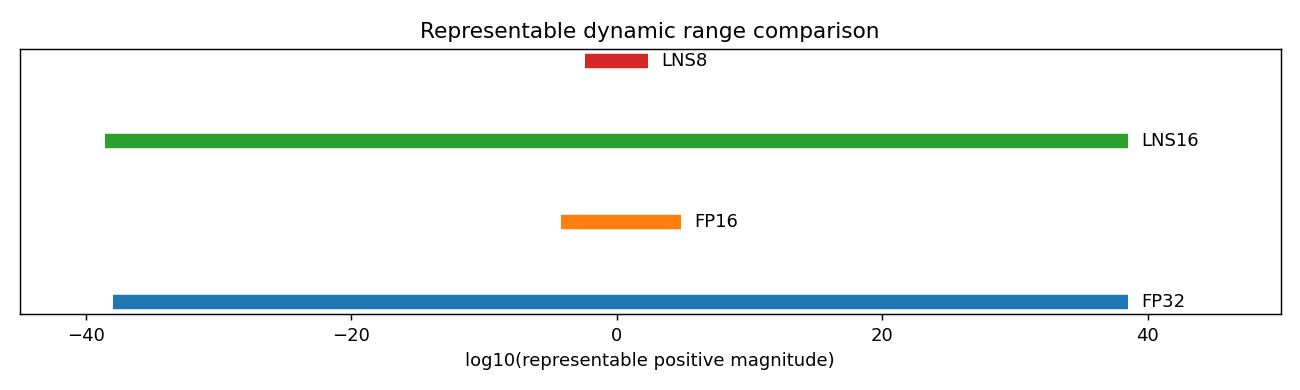

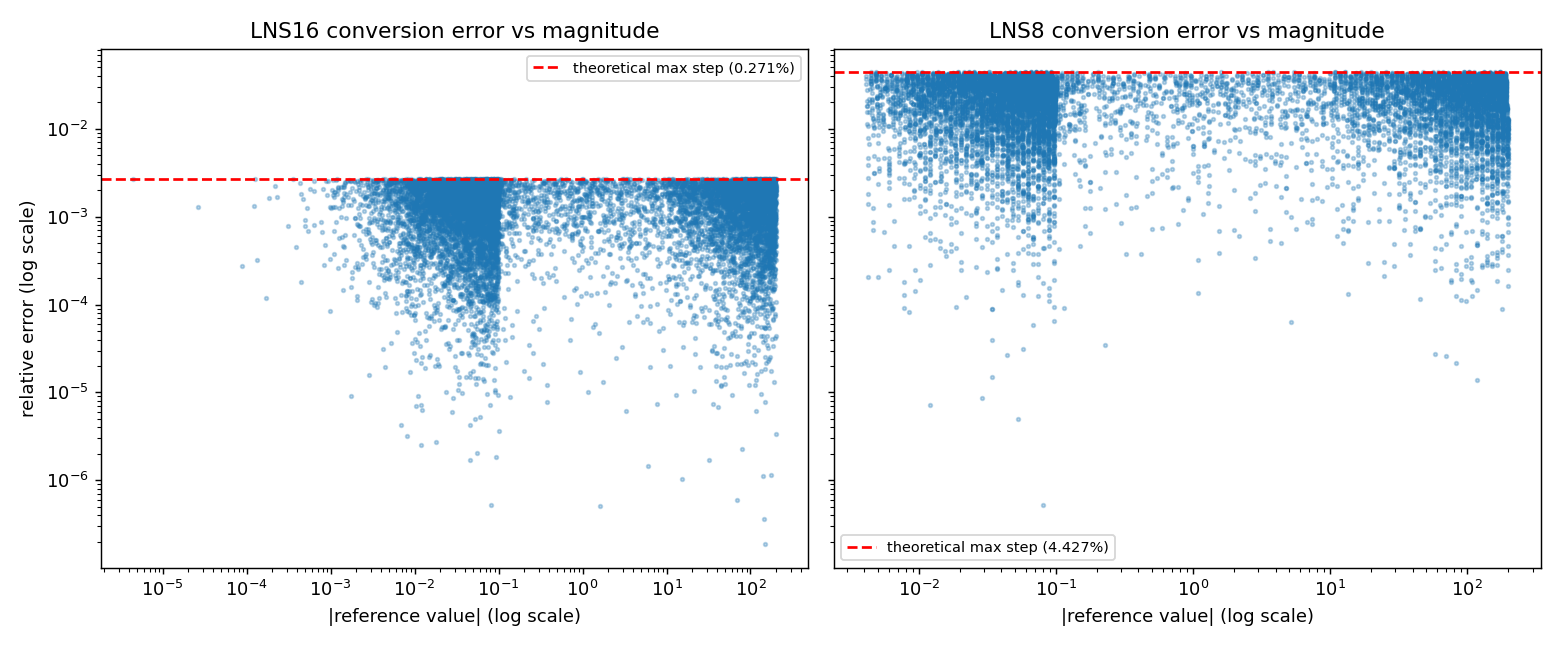

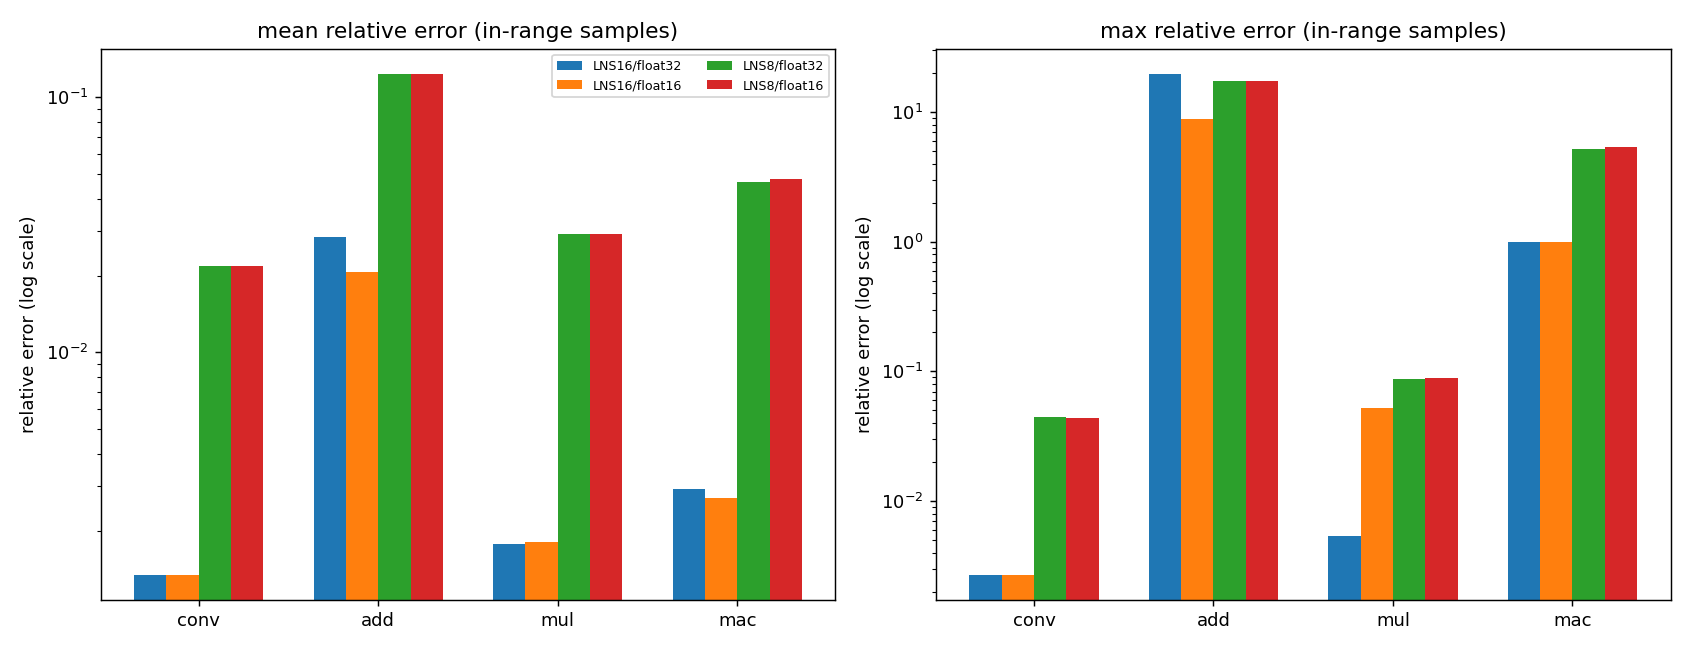

In [ ]:

from IPython.display import Image, display
for fname in ["range_comparison.png", "conversion_error_scatter.png", "error_summary_bars.png"]:
    display(Image(filename=f"figures/{fname}"))


## 6. Discussion -- range and precision vs. FP32 / FP16

**Range.** LNS16 was sized to bracket essentially the entire FP32 normal range (~2.96e-39..3.38e+38
vs. FP32's ~1.18e-38..3.40e+38), and the stress test above confirms it: LNS16 almost never overflows
and only underflows on the extreme tail below FP32's own smallest normal magnitudes. LNS8's window
is genuinely narrow (~4.3e-3..2.35e+2, about 16 octaves), so on the same wide stress test it
overflows or underflows on most samples. That's an intrinsic LNS trade-off: range and precision come
from the same bits (the log field), unlike floating point where the exponent field sets range
independent of mantissa precision. LNS8 spends its 7 log-field bits as 4 range / 3 precision.

**Precision.** An LNS format's relative quantization error is constant across its whole dynamic
range (~0.27% for LNS16, ~4.4% for LNS8 -- the flat error bands in the conversion scatter plot),
whereas an IEEE float's relative error is likewise constant across its normal range but set by
mantissa width (~1.2e-5% for FP32, ~0.098% for FP16). So LNS16, despite matching FP32's range almost
exactly, is roughly 4 orders of magnitude less precise at every magnitude -- 15 log-field bits can't
match 23 mantissa bits of resolution. LNS8 is coarser still, in the same ballpark as aggressive
INT8/FP8-style DNN quantization.

**Multiplication is where LNS wins.** `log(ab) = log(a) + log(b)` is exact in the log domain, so LNS
multiplication adds essentially no error beyond what conversion already introduced (the `mul`
column above tracks `conv` closely), and it replaces a mantissa multiplier with a cheap fixed-point
adder -- why LNS is attractive for MAC-heavy DNN accelerators.

**Addition is where LNS is weaker.** It has no closed-form log-domain identity; the
Gaussian-logarithm method (`F+`/`F-`, implemented both as a closed-form evaluation and as an
explicit lookup table -- `lns_add` vs. `lns_add_lut`) adds a second error source on top of the
operands' own quantization. The `add`/`mac` rows show larger mean error than `mul`, and much larger
max error: catastrophic cancellation, the same effect that afflicts ordinary floating point --
adding two nearly-equal, opposite-sign operands makes the true result close to zero, so a tiny
absolute error becomes a huge relative one (or an exact 100% error if the result underflows to the
reserved zero code). The max-error rows above are dominated by exactly these near-cancellation
cases, deliberately injected into the test set (`force_mag` pairs) so the effect shows up rather
than getting averaged away.

**Practical takeaway.** LNS16 is a plausible drop-in for FP32 tensors where ~0.3% relative error per
operation is acceptable, and multiplication-heavy workloads benefit most. LNS8 only works for
pre-scaled/normalized values known to stay within its narrow range, and accumulation-heavy paths
(MAC, long dot products) should expect meaningfully larger worst-case error than multiplication
alone, mostly from cancellation rather than raw per-value quantization.
